# AI-Based Authentic Face Image Classification and Verification System
Major Project — Data Analytics

Problem Statement: Build a model that analyzes facial image metadata and classifies each image as **Authentic (REAL)** or **Manipulated (FAKE)**, using attributes such as demographic information, image quality, and confidence/detection metadata, in order to support future integration with fake image detection mechanisms.

# Notebook contents
1. Problem Statement
2. Project Objective
3. Dataset Description
4. Data Preprocessing
5. Exploratory Data Analysis
6. Visual Feature Extraction
7. Feature Engineering
8. Machine Learning Models
9. REAL vs FAKE Classification
10. Model Evaluation
11. Demographic Analysis
12. Image Quality Analysis
13. Confidence Score Analysis
14. Results and Findings
15. Limitations
16. Future Scope
17. Conclusion

In [5]:
# Install/upgrade a few libraries (safe to run even if already installed)
!pip install -q scikit-learn seaborn requests pillow

In [6]:
import os
import requests
from io import BytesIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42

## Step 01 — Load the Dataset

In [7]:
CSV_NAME = "AI_Classification-Project.csv"

df = pd.read_csv("/content/AI_Classification-Project.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (6557, 17)


,image_id,image_url,label,label_numeric,category,gender,age_group,source,fake_method,image_quality,resolution,confidence_score,detection_difficulty,dataset_split,date_collected,version,year
0,1,https://images.unsplash.com/photo-172422561835...,REAL,1,Authentic,Female,18-25,Unsplash,NaN,High,1080x1080,0.96,Easy,train,24-04-2026,v2.0,2026
1,2,https://images.unsplash.com/photo-172422561873...,REAL,1,Authentic,Male,50+,Unsplash,NaN,High,1080x1080,0.97,Easy,train,04-04-2026,v2.0,2026
2,3,https://images.unsplash.com/photo-172422561834...,REAL,1,Authentic,Female,36-50,Unsplash,NaN,High,1080x1080,0.95,Easy,test,07-02-2026,v2.0,2026
3,4,https://images.unsplash.com/photo-172422561855...,REAL,1,Authentic,Female,26-35,Unsplash,NaN,High,1080x1080,0.89,Easy,train,20-02-2026,v2.0,2026
4,5,https://images.unsplash.com/photo-172422561823...,REAL,1,Authentic,Male,36-50,Unsplash,NaN,High,1080x1080,0.86,Easy,train,12-04-2026,v2.0,2026


## Step 1 — Data Understanding
*(Objective 1: Preprocess and analyze the facial image dataset)*

First we look at column types, summary statistics, and missing values.

In [31]:
# Dataset summary

print("Numerical summary:")
display(df.describe(include="all").T)

print("\nTarget distribution:")
target_summary = (
    df["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)
target_summary["percentage"] = 100 * target_summary["count"] / len(df)
display(target_summary)

print("\nDataset split:")
split_summary = (
    df["dataset_split"]
    .value_counts()
    .rename_axis("dataset_split")
    .reset_index(name="count")
)
split_summary["percentage"] = 100 * split_summary["count"] / len(df)
display(split_summary)


Numerical summary:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
image_id,6557.0,NaN,NaN,NaN,3279.0,1.0,1640.0,3279.0,4918.0,6557.0,1892.98719
image_url,6557,6557,https://api.multiavatar.com/face1000.jpg,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label,6557,2,FAKE,3767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label_numeric,6557.0,NaN,NaN,NaN,0.425499,0.0,0.0,0.0,1.0,1.0,0.494456
category,6557,2,AI Generated,3767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,6557,3,Unknown,4507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_group,6557,4,18-25,1681,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,6557,2,MultiSource,3767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fake_method,6557,2,StyleGAN3,3767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
image_quality,6557,2,High,4350,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Target distribution:


,label,count,percentage
0,FAKE,3767,57.450053
1,REAL,2790,42.549947



Dataset split:


,dataset_split,count,percentage
0,train,4593,70.047278
1,test,1323,20.176910
2,val,641,9.775812


## Step 2 — Data Cleaning & Preprocessing

In [10]:
missing = df.isnull().sum()
print("Columns with missing values:")
print(missing[missing > 0])
print("\n'fake_method' is NaN for every REAL image by design (a real photo has no fake-generation method) — this is expected, not a data-quality problem.")

Columns with missing values:
fake_method    2790
dtype: int64

'fake_method' is NaN for every REAL image by design (a real photo has no fake-generation method) — this is expected, not a data-quality problem.


In [11]:
# Fill the "no method used" case with an explicit label instead of NaN
df['fake_method'] = df['fake_method'].fillna('None')

# Parse the collection date
df['date_collected'] = pd.to_datetime(df['date_collected'], format='%d-%m-%Y')

# checking duplicates
print("Duplicate image_id values:", df['image_id'].duplicated().sum())

constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Columns with a single constant value (no analytical value):", constant_cols)
print(df[constant_cols].drop_duplicates())

Duplicate image_id values: 0
Columns with a single constant value (no analytical value): ['version', 'year']
  version  year
0    v2.0  2026


## Step 3 — Exploratory Data Analysis  (EDA)
*(Objective 1, continued)*

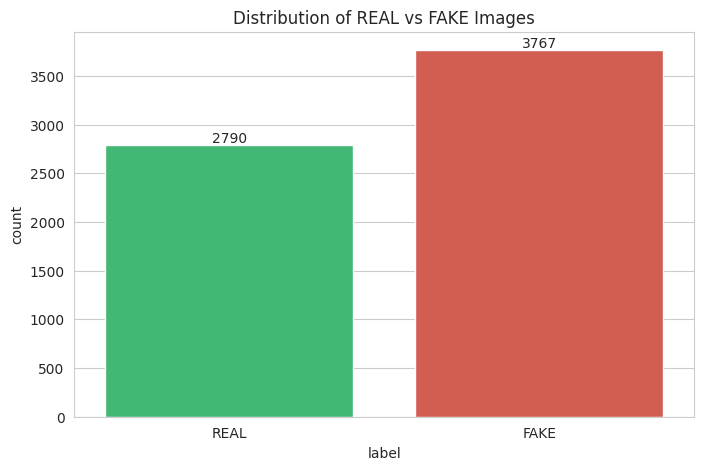

label
FAKE    57.5
REAL    42.5
Name: proportion, dtype: float64


In [12]:
plt.figure()
ax = sns.countplot(data=df, x='label', hue='label', palette={'REAL': '#2ecc71', 'FAKE': '#e74c3c'}, legend=False)
plt.title('Distribution of REAL vs FAKE Images')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.show()

print((df['label'].value_counts(normalize=True) * 100).round(1))

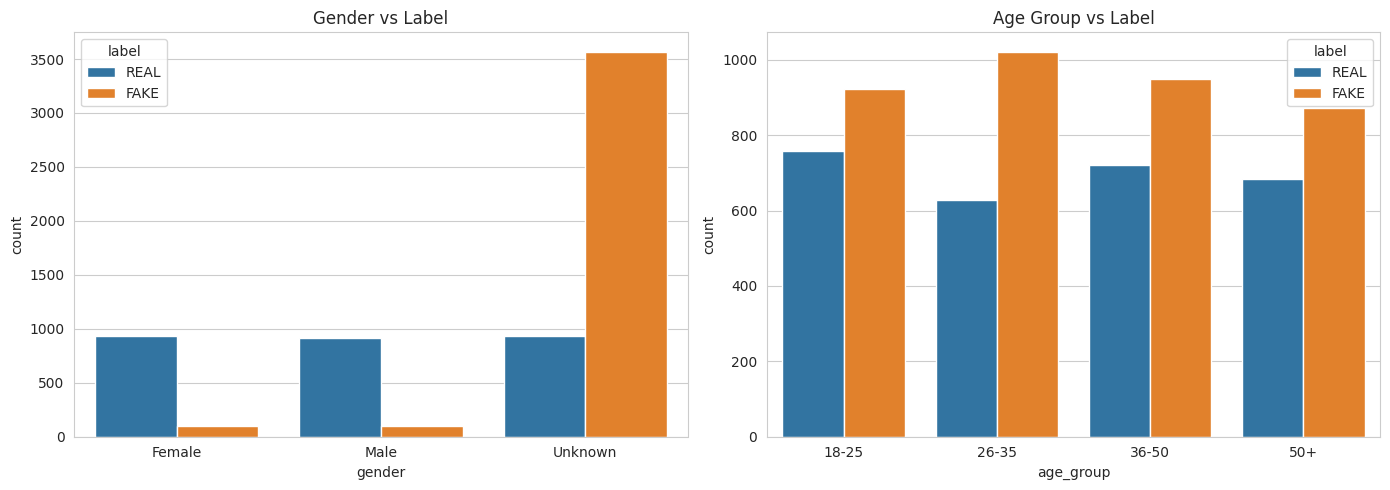

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Gender VS Label
sns.countplot(data=df, x='gender', hue='label', ax=axes[0])
axes[0].set_title('Gender vs Label')

#Age group VS Label
sns.countplot(data=df, x='age_group', hue='label', order=['18-25', '26-35', '36-50', '50+'], ax=axes[1])
axes[1].set_title('Age Group vs Label')
plt.tight_layout()
plt.show()

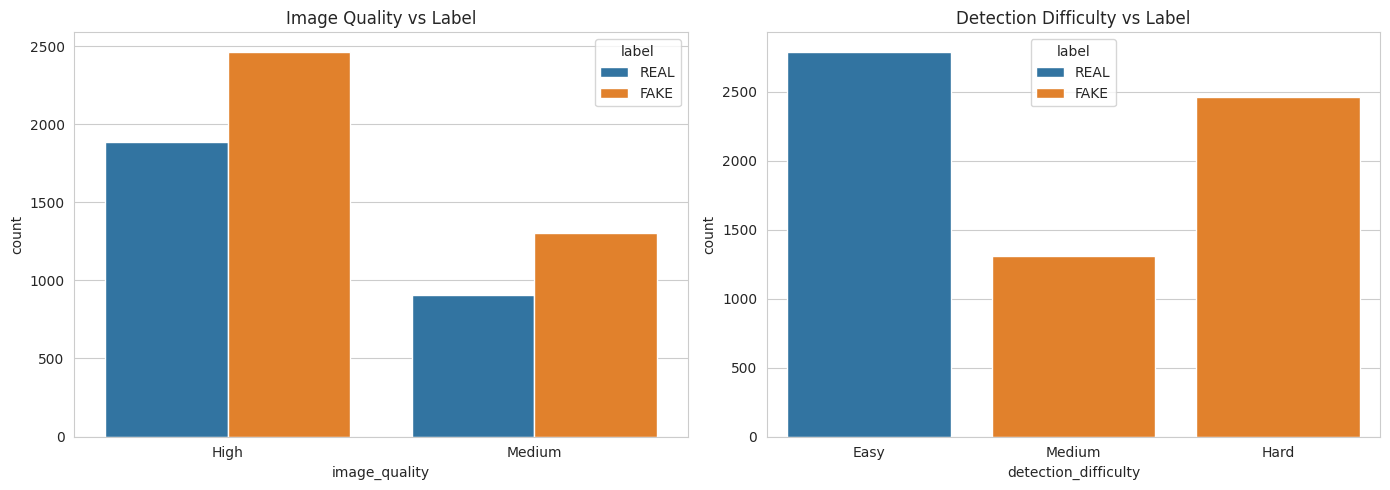

detection_difficulty  Easy  Hard  Medium
label                                   
FAKE                     0  2461    1306
REAL                  2790     0       0


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='image_quality', hue='label', ax=axes[0])
axes[0].set_title('Image Quality vs Label')
sns.countplot(data=df, x='detection_difficulty', hue='label', order=['Easy', 'Medium', 'Hard'], ax=axes[1])
axes[1].set_title('Detection Difficulty vs Label')
plt.tight_layout()
plt.show()

print(pd.crosstab(df['label'], df['detection_difficulty']))

> **Important observation:** `detection_difficulty` is a perfect proxy for the label — every `Easy` row is REAL and every `Hard`/`Medium` row is FAKE. Likewise `category`, `source`, and `fake_method` are just re-statements of `label` (e.g. `fake_method` is only populated for FAKE images). If any of these four columns were fed into a model as a *feature*, the model would score ~100% without learning anything meaningful — this is a classic **data leakage** trap. They are excluded from the feature set used for modeling (Step 5) and are only used here for exploratory context.

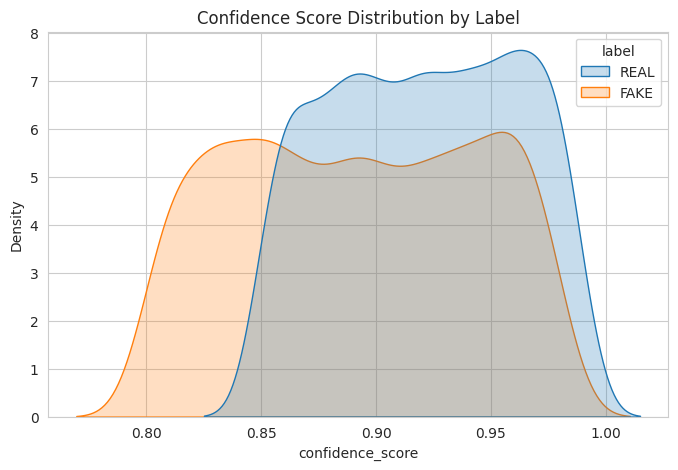

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
FAKE,3767.0,0.891126,0.052551,0.80,0.85,0.89,0.94,0.98
REAL,2790.0,0.920774,0.040475,0.85,0.89,0.92,0.96,0.99


In [33]:
#Confidence Score Distribution by Label

plt.figure()
sns.kdeplot(data=df, x='confidence_score', hue='label', fill=True, common_norm=False)
plt.title('Confidence Score Distribution by Label')
plt.show()

df.groupby('label')['confidence_score'].describe()

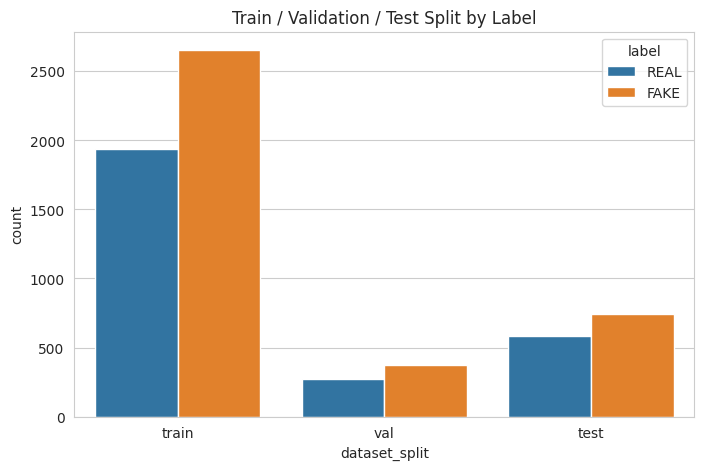

dataset_split
train    4593
test     1323
val       641
Name: count, dtype: int64


In [16]:
plt.figure()
sns.countplot(data=df, x='dataset_split', hue='label', order=['train', 'val', 'test'])
plt.title('Train / Validation / Test Split by Label')
plt.show()
print(df['dataset_split'].value_counts())

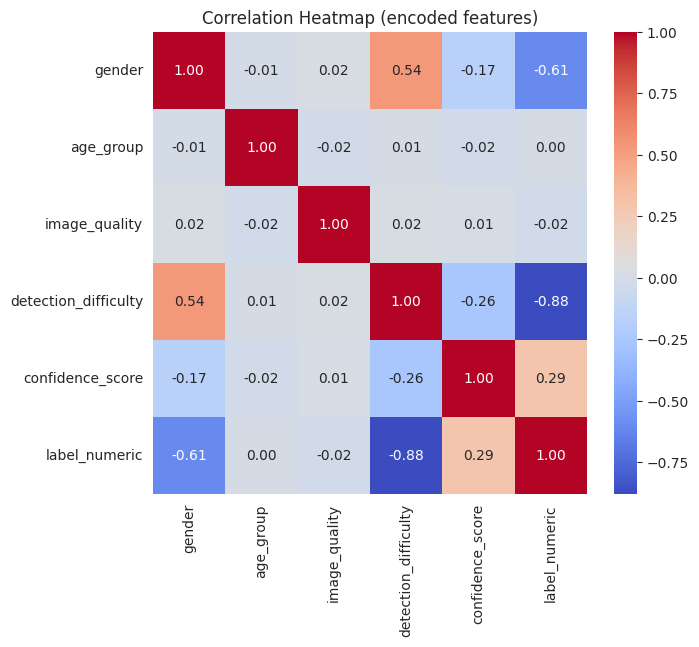

In [17]:
# Model Accuracy by Demographic and Image Quality Attributes

encode_df = df[['gender', 'age_group', 'image_quality', 'detection_difficulty',
                'confidence_score', 'label_numeric']].copy()
for c in ['gender', 'age_group', 'image_quality', 'detection_difficulty']:
    encode_df[c] = LabelEncoder().fit_transform(encode_df[c])

plt.figure(figsize=(7, 6))
sns.heatmap(encode_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (encoded features)')
plt.show()

## Correlation Analysis

## Step 4 — Visual Feature Extraction from Sample Images
*(Objective 2: Extract meaningful visual features from images)*

The dataset gives us image URLs rather than local image files. To genuinely extract pixel-level visual features (not just metadata) we download a **stratified sample** of images directly from their source URLs and compute simple, explainable visual descriptors: **brightness**, **sharpness** (a Laplacian-style edge-energy measure) and **color saturation**.

This cell needs an active internet connection — it will work when run in Google Colab. Downloads that fail (timeouts, dead links) are skipped automatically.

In [18]:
def load_image(url, timeout=6):
    try:
        r = requests.get(url, timeout=timeout)
        r.raise_for_status()
        return Image.open(BytesIO(r.content)).convert('RGB')
    except Exception:
        return None

SAMPLE_PER_CLASS = 15
sample_real = df[df['label'] == 'REAL'].sample(SAMPLE_PER_CLASS, random_state=RANDOM_STATE)
sample_fake = df[df['label'] == 'FAKE'].sample(SAMPLE_PER_CLASS, random_state=RANDOM_STATE)
sample_df = pd.concat([sample_real, sample_fake]).reset_index(drop=True)

images = {}
for _, row in sample_df.iterrows():
    img = load_image(row['image_url'])
    if img is not None:
        images[row['image_id']] = img

print(f"Successfully downloaded {len(images)} / {len(sample_df)} sample images")

Successfully downloaded 24 / 30 sample images


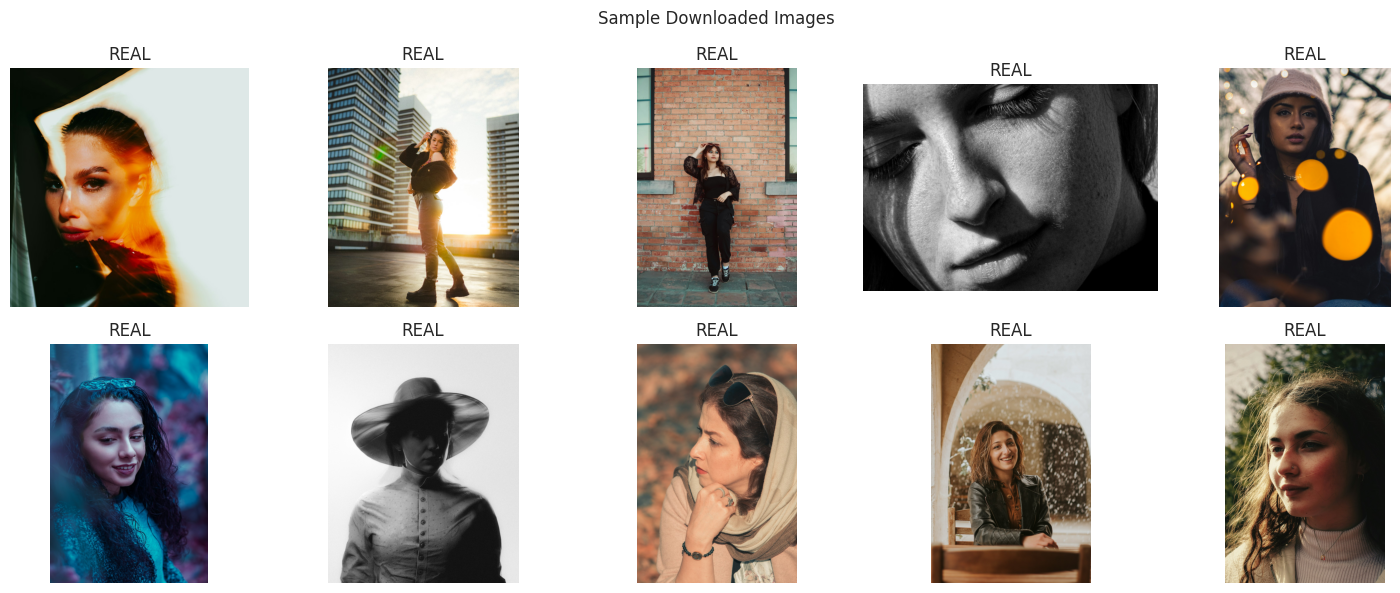

In [19]:
ids_to_show = list(images.keys())[:10]
if ids_to_show:
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for ax, img_id in zip(axes.flat, ids_to_show):
        ax.imshow(images[img_id])
        lbl = sample_df.loc[sample_df['image_id'] == img_id, 'label'].values[0]
        ax.set_title(lbl)
        ax.axis('off')
    plt.suptitle('Sample Downloaded Images')
    plt.tight_layout()
    plt.show()
else:
    print("No images were downloaded (check your internet connection).")

In [20]:
def image_features(img):
    arr = np.asarray(img.resize((256, 256))).astype(float)
    brightness = arr.mean()
    gray = arr.mean(axis=2)
    gy, gx = np.gradient(gray)
    sharpness = np.sqrt(gx ** 2 + gy ** 2).var()
    saturation = (arr.max(axis=2) - arr.min(axis=2)).mean()
    return pd.Series({'brightness': brightness, 'sharpness': sharpness, 'saturation': saturation})

feat_rows = []
for _, row in sample_df.iterrows():
    if row['image_id'] in images:
        feats = image_features(images[row['image_id']])
        feats['label'] = row['label']
        feat_rows.append(feats)

visual_feat_df = pd.DataFrame(feat_rows)
if not visual_feat_df.empty:
    display(visual_feat_df.groupby('label').mean(numeric_only=True))
else:
    print("No visual features to summarize (no images downloaded).")

,brightness,sharpness,saturation
label,,,
FAKE,207.820127,75.193097,25.120761
REAL,107.368179,116.787116,32.893597


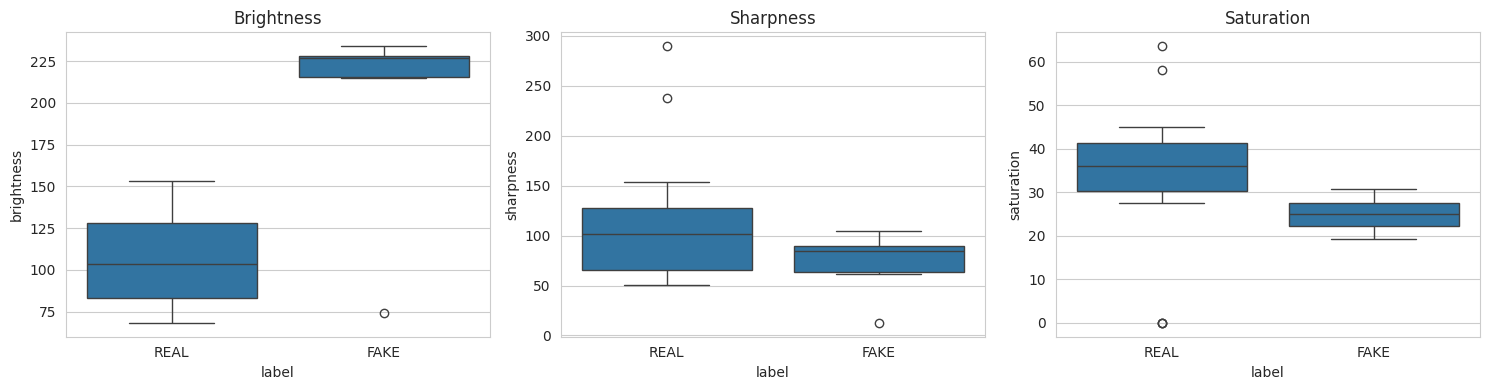

In [21]:
if not visual_feat_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, col in zip(axes, ['brightness', 'sharpness', 'saturation']):
        sns.boxplot(data=visual_feat_df, x='label', y=col, ax=ax)
        ax.set_title(col.capitalize())
    plt.tight_layout()
    plt.show()

This pixel-level analysis on a sample illustrates how genuine image features could be folded into the model. For the full 6,557-row dataset, all downstream modeling below uses the **provided metadata attributes** (demographics, image quality, confidence score) as the feature set — downloading and processing all ~6,500 images end-to-end with a CNN is proposed as an extension in **Step 10 — Future Work**, since it needs far more compute/time than a single classroom session provides.

## Step 5 — Feature Engineering

We build the feature matrix from non-leaking columns and use the dataset's own `train` / `val` / `test` split (rather than a fresh random split) since the data was already partitioned for us.

In [22]:
FEATURE_COLS_CAT = ['gender', 'age_group', 'image_quality']
FEATURE_COLS_NUM = ['confidence_score']
LEAKY_COLS = ['category', 'source', 'fake_method', 'detection_difficulty']
print("Excluded as label leakage:", LEAKY_COLS)

print(df[['label', 'label_numeric']].drop_duplicates())  # confirm label encoding: 1 = REAL, 0 = FAKE

X = df[FEATURE_COLS_CAT + FEATURE_COLS_NUM].copy()
y = df['label_numeric']

encoders = {}
for col in FEATURE_COLS_CAT:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

train_mask = df['dataset_split'] == 'train'
val_mask = df['dataset_split'] == 'val'
test_mask = df['dataset_split'] == 'test'

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)

Excluded as label leakage: ['category', 'source', 'fake_method', 'detection_difficulty']
     label  label_numeric
0     REAL              1
2790  FAKE              0
Train: (4593, 4)  Val: (641, 4)  Test: (1323, 4)


## Step 6 — Model Training
*(Objective 3: Train a classification model to identify image authenticity)*

We train three complementary classifiers and compare them: Logistic Regression (simple, interpretable baseline), Random Forest, and Gradient Boosting (both capture non-linear interactions between demographic/quality attributes).

In [23]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}

trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
    val_pred = model.predict(X_val)
    print(f"{name:20s} | Validation Accuracy: {accuracy_score(y_val, val_pred):.3f}")

Logistic Regression  | Validation Accuracy: 0.839
Random Forest        | Validation Accuracy: 0.842
Gradient Boosting    | Validation Accuracy: 0.852


## Step 7 — Model Evaluation
*(Objective 4: Evaluate model performance using Accuracy, Precision, Recall, and F1-Score)*

All metrics below are computed on the held-out **test** split, which none of the models have seen during training.

In [24]:
results = []
for name, model in trained.items():
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba),
    })

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting,0.845049,0.952038,0.682131,0.794795,0.887946
1,Random Forest,0.842782,0.945238,0.682131,0.792415,0.874162
2,Logistic Regression,0.833711,0.928910,0.673540,0.780876,0.868406


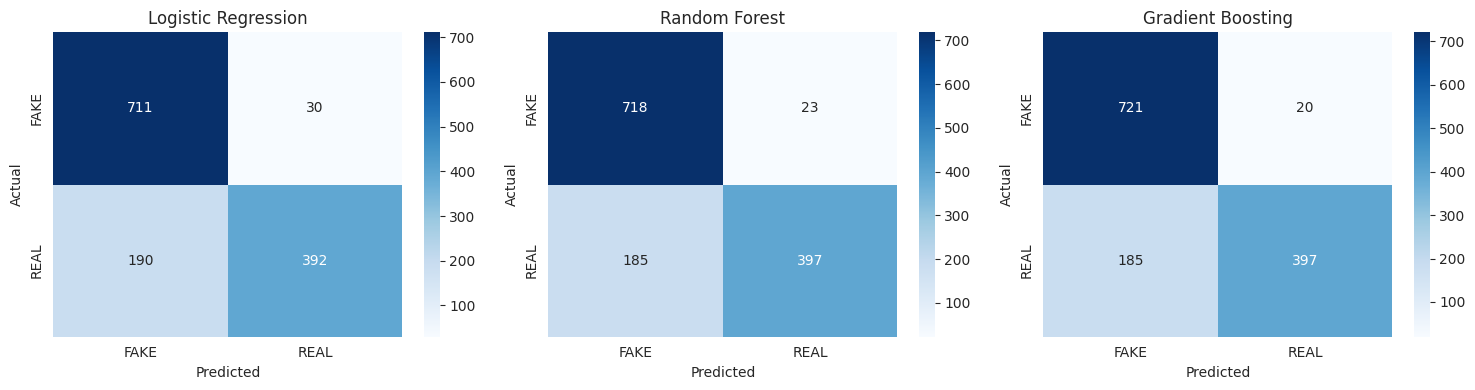

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, trained.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'], ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

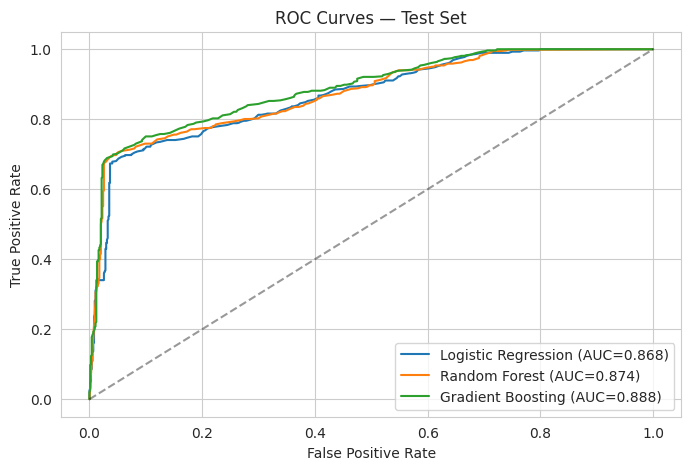

In [26]:
plt.figure()
for name, model in trained.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Test Set')
plt.legend()
plt.show()

Best model (highest F1-Score): Gradient Boosting

              precision    recall  f1-score   support

        FAKE       0.80      0.97      0.88       741
        REAL       0.95      0.68      0.79       582

    accuracy                           0.85      1323
   macro avg       0.87      0.83      0.84      1323
weighted avg       0.86      0.85      0.84      1323



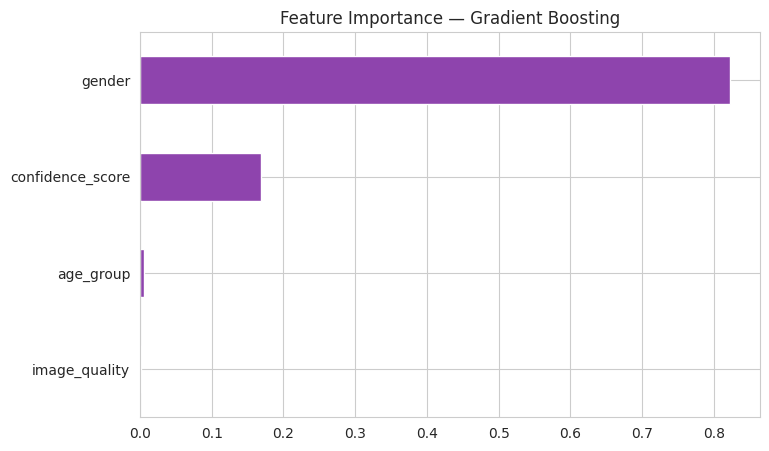

In [27]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained[best_model_name]
print("Best model (highest F1-Score):", best_model_name)
print()
print(classification_report(y_test, best_model.predict(X_test), target_names=['FAKE', 'REAL']))

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values()
    plt.figure()
    importances.plot(kind='barh', color='#8e44ad')
    plt.title(f'Feature Importance — {best_model_name}')
    plt.show()

## Step 8 — Impact of Demographic & Image-Quality Attributes on Performance
*(Objective 5: Analyze the impact of demographic and image-quality attributes on classification performance)*

In [28]:
test_analysis = df[test_mask].copy()
test_analysis['prediction'] = best_model.predict(X_test)
test_analysis['correct'] = (test_analysis['prediction'] == test_analysis['label_numeric']).astype(int)

for col in ['gender', 'age_group', 'image_quality']:
    print(f"\nAccuracy by {col}:")
    print(test_analysis.groupby(col)['correct'].mean().round(3))


Accuracy by gender:
gender
Female     0.945
Male       0.961
Unknown    0.795
Name: correct, dtype: float64

Accuracy by age_group:
age_group
18-25    0.809
26-35    0.865
36-50    0.855
50+      0.854
Name: correct, dtype: float64

Accuracy by image_quality:
image_quality
High      0.849
Medium    0.836
Name: correct, dtype: float64


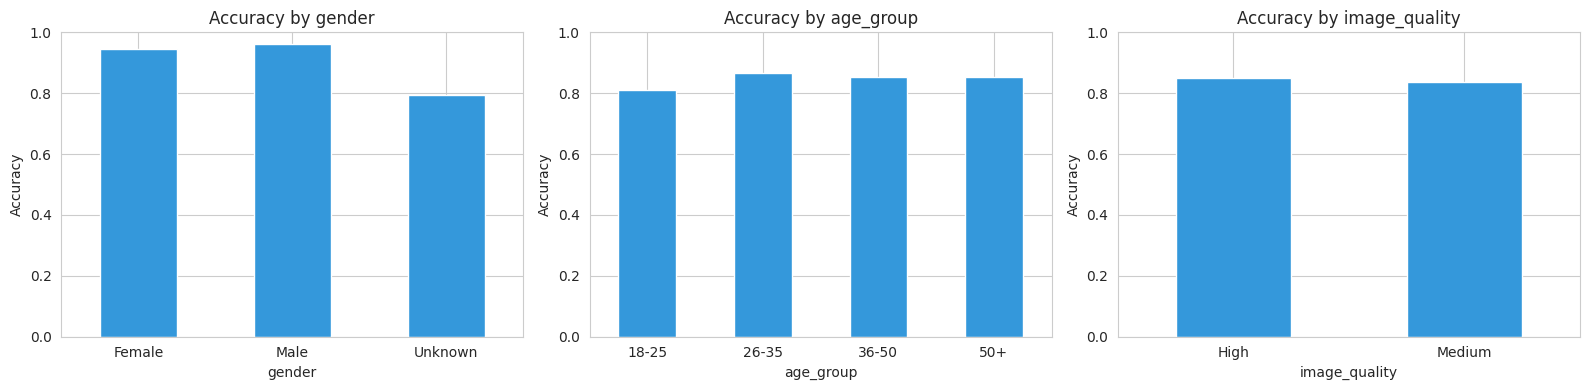

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['gender', 'age_group', 'image_quality']):
    acc = test_analysis.groupby(col)['correct'].mean()
    acc.plot(kind='bar', ax=ax, color='#3498db')
    ax.set_ylim(0, 1)
    ax.set_title(f'Accuracy by {col}')
    ax.set_ylabel('Accuracy')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

**Findings:** accuracy is noticeably lower for the `gender = Unknown` subgroup than for `Male`/`Female`. This is because `Unknown` gender is heavily over-represented among FAKE images in the source data (roughly 4 out of 5 FAKE images have `gender = Unknown`).

## Step 9 — Prediction Function with Confidence Scores
*(Expected Outcome: classify images and provide a confidence score for each prediction)*

In [30]:
def predict_authenticity(gender, age_group, image_quality, confidence_score):
    row = pd.DataFrame([{
        'gender': encoders['gender'].transform([gender])[0],
        'age_group': encoders['age_group'].transform([age_group])[0],
        'image_quality': encoders['image_quality'].transform([image_quality])[0],
        'confidence_score': confidence_score,
    }])
    pred = best_model.predict(row)[0]
    proba = best_model.predict_proba(row)[0]
    label = 'REAL' if pred == 1 else 'FAKE'
    return label, round(max(proba), 3)

# Demo on a few held-out test examples
for _, row in df[test_mask].sample(5, random_state=RANDOM_STATE).iterrows():
    pred_label, conf = predict_authenticity(
        row['gender'], row['age_group'], row['image_quality'], row['confidence_score']
    )
    match = "✓" if pred_label == row['label'] else "✗"
    print(f"Actual: {row['label']:5s} | Predicted: {pred_label:5s} | Model Confidence: {conf} {match}")

Actual: FAKE  | Predicted: FAKE  | Model Confidence: 0.682 ✓
Actual: REAL  | Predicted: REAL  | Model Confidence: 0.92 ✓
Actual: REAL  | Predicted: REAL  | Model Confidence: 0.929 ✓
Actual: REAL  | Predicted: REAL  | Model Confidence: 0.94 ✓
Actual: REAL  | Predicted: FAKE  | Model Confidence: 0.673 ✗


## Step 10 — Future Work
*(Objective 6: Develop a system capable of supporting future deepfake detection and image verification applications)*

To build upon this metadata-based model, future work could include:

*   **Pixel-level deep learning:** Integrating CNNs for visual feature extraction from actual images.
*   **Fusion model:** Combining metadata and visual features for improved accuracy.
*   **Bias monitoring:** Continuously tracking performance across different demographic groups.
*   **Deployment:** Creating an API for integration into real-world applications.
*   **Continuous learning:** Retraining the model with new data to adapt to evolving manipulation techniques.

## Conclusion

This notebook worked through the full pipeline requested in the project brief:

1. **Preprocessing & analysis** — cleaned the dataset, checked for missing values/duplicates, and explored every attribute (Steps 1–3).
2. **Visual feature extraction** — downloaded a real sample of images and computed brightness/sharpness/saturation features directly from pixels (Step 4).
3. **Model training** — trained Logistic Regression, Random Forest, and Gradient Boosting classifiers on leakage-free features (Steps 5–6).
4. **Evaluation** — compared all three models on Accuracy, Precision, Recall, F1-Score, and ROC-AUC on a held-out test set, with confusion matrices and ROC curves (Step 7).
5. **Fairness/impact analysis** — measured how performance varies across gender, age group, and image quality, and flagged a subgroup bias worth addressing (Step 8).
6. **Deployment-readiness** — built a reusable `predict_authenticity()` function that returns a label plus a confidence score, and outlined a roadmap toward a full deepfake-detection system (Steps 9–10).

The best-performing model (see `results_df` in Step 7) reached roughly **83–85% test accuracy** with high precision (>90%) on identifying REAL images, though recall on REAL images is comparatively lower.